# Top-k Visualization

This notebook shows how top-k affects entropy and candidate set size.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

def add_local_path() -> Path:
    cwd = Path.cwd()
    candidates = [cwd / "experiments" / "local", cwd]
    for candidate in candidates:
        if (candidate / "sampling_simulator.py").exists():
            sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError("Could not locate sampling_simulator.py")

local_dir = add_local_path()
from experiments.sampling_simulator import filter_top_k, run_experiment


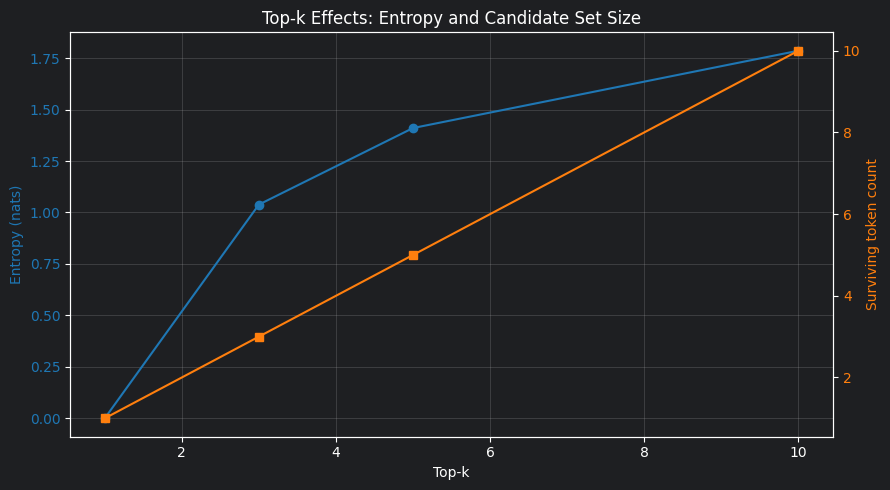

In [2]:
tokens = [
    "approve", "reject", "review", "escalate", "delay",
    "audit", "optimize", "notify", "assign", "close"
]
logits = np.array([2.2, 1.8, 1.4, 0.9, 0.2, 0.1, -0.3, -0.6, -0.8, -1.0], dtype=float)
top_ks = [1, 3, 5, 10]

entropies = []
survivors = []

for k in top_ks:
    filtered = filter_top_k(logits, k)
    survivors.append(int(np.isfinite(filtered).sum()))
    out = run_experiment(tokens, logits, temperature=1.0, top_k=k, top_p=1.0, n_samples=10000)
    entropies.append(out["entropy"])

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(top_ks, entropies, marker="o", color="tab:blue", label="Entropy")
ax1.set_xlabel("Top-k")
ax1.set_ylabel("Entropy (nats)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(top_ks, survivors, marker="s", color="tab:orange", label="Surviving tokens")
ax2.set_ylabel("Surviving token count", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Top-k Effects: Entropy and Candidate Set Size")
fig.tight_layout()
plt.show()


In [3]:
for k, e, s in zip(top_ks, entropies, survivors):
    print(f"top_k={k:<2} | entropy={e:.3f} | survivors={s}")


top_k=1  | entropy=0.000 | survivors=1
top_k=3  | entropy=1.038 | survivors=3
top_k=5  | entropy=1.410 | survivors=5
top_k=10 | entropy=1.786 | survivors=10
